# Recommendation Systems

Recommendation systems are used to suggest products to users based on their past preferences. Recommendation systems are generally divided into the following categories:

- **Content-based**: Based on the similarity between product features (e.g. keywords, categories) and user preferences.  
  For example, if a user liked Product A, the recommendation system suggests products with similar features. In the context of movies, these features could be director, genre, etc. This approach can typically be implemented with a supervised binary classification algorithm.

- **Collaborative filtering**: Computes similarity from user–item interactions (e.g. ratings, purchase counts, likes, etc.).  
  This method finds customers with similar preferences and then recommends items they haven't experienced yet but that similar customers have preferred. The system assumes that users with similar movie-watching habits generally have similar tastes. It finds other users who watch videos similar to what the target user watches, then recommends videos those users have watched but the target user hasn't. There are 3 types: user–user collaborative filtering, item–item collaborative filtering, and matrix factorization.

- Newer and generally more powerful approaches are **Hybrid systems**.  
  These systems combine the two methods mentioned above.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/06-Unsupervised-Learning/recommendation_systems.png" width=600>

The diagram above provides a detailed classification of the different methodologies used to build a recommendation system.

In the context of `movieLens`, which will be used as a sample dataset later:
- We can recommend different movies based on content similarity (e.g. genre, cast, etc.); this applies **item-content filtering**.
- By comparing user metadata (e.g. age, gender), we could recommend items liked by similar users; this would use **user-content filtering**. However, since the `movieLens` dataset does not contain user content data, we will only build **item-item collaborative filtering**.

**Memory-based content filtering**

In memory-based methods, there is no model that learns from data and makes predictions. Instead, a **pre-computed similarity matrix** is created that can be used for movie recommendations.

## Data Collection and Cleaning

Run the lines below to download the required datasets. Then load the datasets into three separate pandas DataFrames (`movies`, `tags`, and `ratings`).

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_ratings.csv > data/movies.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_tags.csv > data/tags.csv
!curl https://d32aokrjazspmn.cloudfront.net/materials/movie_titles.csv > data/ratings.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2425k  100 2425k    0     0  2416k      0  0:00:01  0:00:01 --:--:-- 2418k     0      0 --:--:-- --:--:-- --:--:--     0
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  115k  100  115k    0     0   362k      0 --:--:-- --:--:-- --:--:--  362k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  482k  100  4816    0     0   148k      0  0:00:03 --:--:--  0:00:03  147k2k    0     0   822k      0 --:--:-- --:--:-- --:--:--  822k


In [22]:
import pandas as pd

movies = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')
ratings = pd.read_csv('data/movies.csv')

__Remove the '|' character that separates different movie genres and replace it with a space.__

In [31]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [28]:
movies["genres"] = movies["genres"].str.replace("|", " ")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


__Filter the `movies` DataFrame to keep only movies that have received a rating.__

In [26]:
movies = movies[movies['movieId'].isin(ratings['movieId'])]

### 🧪 Test Your Code

In [27]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'datasets',
    movies_shape=movies.shape,
    tags_shape=tags.shape,
    ratings_shape=ratings.shape,
    genres_cleaned=movies['genres'].str.find('|') >= 0
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-movie-recommendation/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 4 items

test_datasets.py::TestDatasets::test_genres_are_cleaned PASSED           [ 25%]
test_datasets.py::TestDatasets::test_movies_shape PASSED                 [ 50%]
test_datasets.py::TestDatasets::test_ratings_shape PASSED                [ 75%]
test_datasets.py::TestDatasets::test_tags_shape PASSED                   [100%]

============================== 4 passed in 0.49s ===============================


💯 You can commit your code:

git add tests/datasets.pickle

git commit -m 'Completed datasets step'

git push origin master



## Feature Engineering

We will create a new feature called `metadata` that combines **all the text data** we have about a movie — its genres and tags.

__Merge the `movies` and `tags` DataFrames.__

In [40]:
metadata = pd.merge(movies, tags, on='movieId', how='left')
metadata

,movieId,title,genres,userId,tag,timestamp
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,336.0,pixar,1.139046e+09
1,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,474.0,pixar,1.137207e+09
2,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,567.0,fun,1.525286e+09
3,2,Jumanji (1995),Adventure Children Fantasy,62.0,fantasy,1.528844e+09
4,2,Jumanji (1995),Adventure Children Fantasy,62.0,magic board game,1.528844e+09
...,...,...,...,...,...,...
11827,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy,NaN,NaN,NaN
11828,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy,NaN,NaN,NaN
11829,193585,Flint (2017),Drama,NaN,NaN,NaN
11830,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation,NaN,NaN,NaN


**Create a new `merged_df` DataFrame containing a `metadata` column. This column should be formed by concatenating both the tags and the genres.**

To do this:
- First, **aggregate the tags** per movie.
- Then, concatenate those aggregated tags with the **genres** column.

For example, the `metadata` column for the movie *Toy Story* should look like:  
`pixar pixar fun Adventure Animation Children Comedy Fantasy`

👉 `merged_df` should contain at least the following columns: `movieId`, `title`, and `metadata`.

In [41]:
metadata["tag"] = metadata["tag"].fillna('')

In [43]:
merged_df = (
    metadata
    .groupby(['movieId', 'title', 'genres'])['tag']
    .apply(' '.join)
    .reset_index()
)

merged_df['metadata'] = (merged_df['tag'] + ' ' + merged_df['genres']).str.strip()
merged_df = merged_df[['movieId', 'title', 'metadata']]

In [44]:
merged_df.head()

,movieId,title,metadata
0,1,Toy Story (1995),pixar pixar fun Adventure Animation Children C...
1,2,Jumanji (1995),fantasy magic board game Robin Williams game A...
2,3,Grumpier Old Men (1995),moldy old Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),pregnancy remake Comedy


### 🧪 Test Your Code

In [46]:
from nbresult import ChallengeResult
import numpy as np

result = ChallengeResult(
    'feature_engineering',
    unique_movies=np.all(merged_df[['movieId']].value_counts() > 1),
    metadata=merged_df[merged_df['title'] == 'Copycat (1995)'],
    merged_df_rows=merged_df.shape[0]
)

result.write()
print(result.check())

============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-movie-recommendation/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 4 items

test_feature_engineering.py::TestFeatureEngineering::test_merged_df_rows PASSED [ 25%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_genres PASSED [ 50%]
test_feature_engineering.py::TestFeatureEngineering::test_metadata_has_tags PASSED [ 75%]
test_feature_engineering.py::TestFeatureEngineering::test_unicity_of_movies PASSED [100%]

============================== 4 passed in 0.44s ===============================



## Building a Content Latent Matrix from Metadata

### Count Vectorizer

In the next step, we need to convert the metadata texts into vectors so we can feed them into machine learning algorithms. Machine learning models cannot directly understand text data, so we need to encode it.

For this purpose, we will encode the `metadata` column using [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html).

Create a new `count_df` DataFrame from the vectors obtained after the count transformation.  
Each row will represent the **frequency vector** of the corresponding movie.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

encoder = CountVectorizer()

count_df = pd.DataFrame(
    encoder.fit_transform(merged_df['metadata']).toarray(),
    index=merged_df['title'],
    columns=encoder.get_feature_names_out()
)

count_df

,06,1900s,1920s,1950s,1960s,1970s,1980s,1990s,2001,250,...,york,you,younger,your,zellweger,zither,zoe,zombie,zombies,zooey
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Jumanji (1995),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Grumpier Old Men (1995),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Waiting to Exhale (1995),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Father of the Bride Part II (1995),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Black Butler: Book of the Atlantic (2017),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
No Game No Life: Zero (2017),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Flint (2017),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Dimensionality Reduction

Each movie's metadata was converted into a vector of approximately **1675 dimensions**!

As we saw in previous lessons, we can apply **dimensionality reduction** methods to represent the data (movies) with minimal information loss. **Truncated Singular Value Decomposition (SVD)** is another advanced tool used for dimensionality reduction.

Unlike PCA, this method **does not center the data before computing the singular value decomposition (SVD)**. This makes it capable of **working efficiently with sparse matrices**. It works particularly well on term count / frequency matrices. In this context, it is also known as **Latent Semantic Analysis (LSA)**.

You can look at the [`TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) class in Scikit-Learn; the principle is the same as PCA.

__👉 **Apply Truncated SVD to reduce the dimensionality of your count matrix (e.g. to 25 features).**__


In [50]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=25)

latent_df = pd.DataFrame(
    svd.fit_transform(count_df),
    index=count_df.index,
    columns=["LSA_" + str(i) for i in range(25)]
)

latent_df

,LSA_0,LSA_1,LSA_2,LSA_3,LSA_4,LSA_5,LSA_6,LSA_7,LSA_8,LSA_9,...,LSA_15,LSA_16,LSA_17,LSA_18,LSA_19,LSA_20,LSA_21,LSA_22,LSA_23,LSA_24
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),0.906692,0.970036,-0.641471,-0.496960,0.916133,0.981349,-0.730853,0.425908,0.067736,-0.213435,...,-0.085086,-0.106250,-0.208170,0.018188,0.003559,-0.037862,-0.075538,-0.007421,-0.037174,0.000034
Jumanji (1995),0.412862,0.161880,-0.589252,-0.697596,1.038237,1.269791,-0.500754,0.380975,0.386512,0.337164,...,0.409268,0.399669,-0.213371,-0.017971,0.009863,-0.013609,-0.090186,-0.023527,-0.014242,0.002377
Grumpier Old Men (1995),0.765446,0.916198,0.122466,0.017971,-0.282143,0.207786,0.653589,0.063256,-0.031728,0.003956,...,-0.009017,-0.010493,-0.061513,0.004676,-0.004102,0.005235,0.004708,0.005211,-0.001971,-0.000214
Waiting to Exhale (1995),1.413515,0.502954,0.641908,-0.224913,-0.260731,0.089353,0.437789,-0.029137,-0.023579,-0.003618,...,0.018886,-0.047970,-0.075586,0.007854,-0.012688,-0.001294,0.006789,0.005493,0.002420,-0.000628
Father of the Bride Part II (1995),0.523546,0.780180,-0.056380,0.187794,-0.098299,-0.146546,-0.155238,-0.109085,-0.106509,0.029023,...,-0.017587,-0.021178,-0.006054,0.006068,-0.004712,0.011693,0.004080,0.012449,-0.014892,-0.000602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Black Butler: Book of the Atlantic (2017),0.923070,0.708357,-0.714679,-0.036255,0.687487,0.097475,-0.067340,-0.220634,0.445548,-0.729989,...,-0.458401,-0.455709,-0.015421,0.038345,0.004435,0.001030,-0.084289,0.013889,-0.016123,-0.000496
No Game No Life: Zero (2017),0.677375,0.875444,-0.264824,-0.083239,0.268856,0.424415,-0.435810,0.173715,0.284514,-0.471362,...,-0.514632,-0.502297,-0.001288,0.024368,0.025750,-0.013421,-0.052982,0.031318,-0.010950,-0.001240
Flint (2017),0.648302,-0.412697,0.519522,-0.242865,0.021040,-0.118087,-0.214689,-0.092254,0.008059,-0.007562,...,0.027853,-0.037538,-0.014474,0.003228,-0.008633,-0.006462,0.002143,0.000356,0.004352,-0.000419


👉 **Plot the total explained variance ratio as a function of the number of components.**

Text(0.5, 1.0, 'Explained Variance Ratio vs. Number of Components')

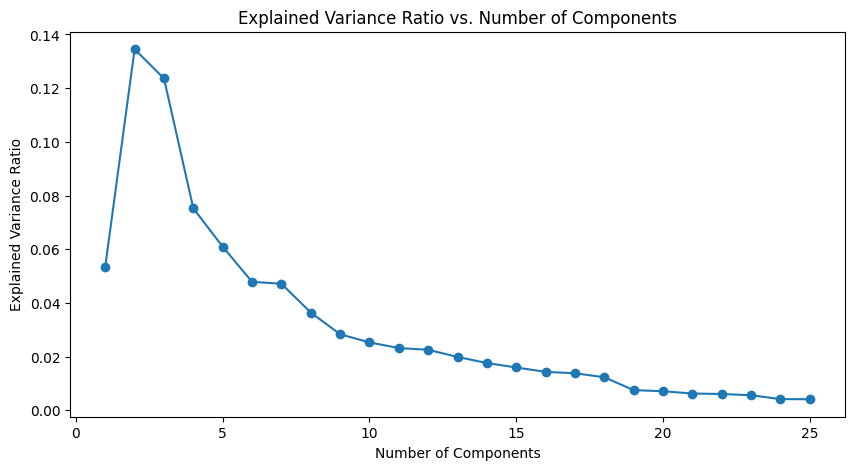

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, 26), svd.explained_variance_ratio_, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio vs. Number of Components')

With only the first 25 components (out of ~1700 originally), we can explain **more than 80%** of the variance, which is sufficient for our purposes.

👉 **Save the 25 components of this matrix into a new `latent_df` DataFrame indexed by movie titles.**

### 🧪 Test Your Code

In [52]:
from nbresult import ChallengeResult

result =  ChallengeResult(
    'metadata',
    counter_shape=count_df.shape,
    latent_shape=latent_df.shape
)

result.write()
print(result.check())

============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-movie-recommendation/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 3 items

test_metadata.py::TestMetadata::test_counter_columns PASSED              [ 33%]
test_metadata.py::TestMetadata::test_counter_rows PASSED                 [ 66%]
test_metadata.py::TestMetadata::test_features_number PASSED              [100%]

============================== 3 passed in 0.01s ===============================



## Building a Latent Matrix from User Ratings

Beyond metadata, we have another valuable source of information: **user ratings**.

A recommendation system can suggest a similar movie based on user ratings (item-to-item collaborative filtering).

👉 **We prepare the following dataset with movies as rows and `userId`s as columns.**

In [53]:
# Merge
ratings1 = pd.merge(movies[['movieId']], ratings, on="movieId", how="right")
# Pivot
ratings2 = ratings1.pivot(index = 'movieId', columns ='userId', values = 'rating').fillna(0)
display(ratings2.head())
ratings2.shape

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


(9724, 610)

We created a dataset containing user ratings as vectors of length 9724.

👉 **Again, we will apply SVD to the `ratings2` DataFrame, keeping the first 200 components. Name this DataFrame `latent_df_2`.**

In [56]:
svd2 = TruncatedSVD(n_components=200)

latent_df_2 = pd.DataFrame(
    svd2.fit_transform(ratings2),
    index=ratings2.index,
    columns=["LSA_" + str(i) for i in range(200)]
)

**👉 Re-index by Movie Title.**

In [57]:
latent_df_2.index = movies.set_index('movieId')['title']

In [58]:
latent_df_2.shape

(9724, 200)

In [59]:
latent_df_2

,LSA_0,LSA_1,LSA_2,LSA_3,LSA_4,LSA_5,LSA_6,LSA_7,LSA_8,LSA_9,...,LSA_190,LSA_191,LSA_192,LSA_193,LSA_194,LSA_195,LSA_196,LSA_197,LSA_198,LSA_199
title,,,,,,,,,,,,,,,,,,,,,
Toy Story (1995),37.649828,-6.380094,-14.994617,-0.286947,1.887147,-4.790050,-8.807629,-2.198637,-1.153304,-1.387560,...,3.637299,0.179814,0.173721,-1.889091,0.025144,-0.872224,1.346697,0.225084,1.859650,2.243863
Jumanji (1995),20.596193,-0.477880,-10.865916,8.635795,3.072411,0.517149,-4.359214,-3.821408,3.394116,-0.236475,...,-0.293869,-1.266196,0.937514,-0.887209,0.425432,-0.442631,-0.886628,-0.068193,0.473314,-2.371274
Grumpier Old Men (1995),8.504182,-5.714924,-3.441693,6.382810,-0.024162,0.783432,1.423027,-0.542291,-3.270655,-1.897237,...,0.342603,0.129838,-0.522346,0.107245,-0.868286,0.744566,0.530397,-0.706258,-1.527838,0.590710
Waiting to Exhale (1995),0.465720,-0.828101,-0.954583,0.239080,0.735695,0.877414,-0.214720,-0.527368,-0.079467,-0.015617,...,0.194583,-0.030048,0.016951,0.032711,0.148779,-0.393384,-0.174668,0.076896,0.092471,-0.276120
Father of the Bride Part II (1995),6.071045,-2.673536,-4.698195,4.415807,3.714221,1.673627,-1.297653,-1.308023,-1.325734,-1.229591,...,0.187008,0.181731,-0.476109,-0.111613,0.440320,0.548157,-0.257001,0.341749,-0.275305,0.994378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Black Butler: Book of the Atlantic (2017),0.039507,0.157924,0.019030,-0.009546,-0.024836,0.164105,-0.182753,0.071143,-0.009693,0.046211,...,0.154762,0.403134,0.442667,-0.250729,-0.047249,0.321926,-0.632826,0.343800,0.133750,-0.127526
No Game No Life: Zero (2017),0.034568,0.138184,0.016651,-0.008353,-0.021732,0.143591,-0.159909,0.062250,-0.008481,0.040434,...,0.135417,0.352743,0.387334,-0.219388,-0.041343,0.281685,-0.553723,0.300825,0.117031,-0.111585
Flint (2017),0.034568,0.138184,0.016651,-0.008353,-0.021732,0.143591,-0.159909,0.062250,-0.008481,0.040434,...,0.135417,0.352743,0.387334,-0.219388,-0.041343,0.281685,-0.553723,0.300825,0.117031,-0.111585


### 🧪 Test Your Code

In [60]:
from nbresult import ChallengeResult

result = ChallengeResult('ratings', latent_shape=latent_df_2.shape)

result.write()
print(result.check())

============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-movie-recommendation/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_ratings.py::TestRatings::test_latent_shape PASSED                   [100%]

============================== 1 passed in 0.01s ===============================



## Applying Cosine Similarity on Content and Collaborative Matrices

In the next step, we will use a similarity measure to find the **top $ movies most similar to "Toy Story"** based on the filtering methods we built. One similarity measure we can use is **Cosine Similarity**. Scikit-learn provides the [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) function for this.

👉 **Compute the cosine similarity for a sample movie ("Toy Story") against both the content (metadata) and collaborative (ratings) latent matrices.**

In [ ]:
# YOUR CODE HERE

We can also build a hybrid filter that averages the similarity of content and collaborative filtering.

`hybrid_similarity = (content_similarity + collaborative_similarity) / 2`

__Compute the average similarity of content and collaborative filtering.__

In [ ]:
# YOUR CODE HERE

__Create a DataFrame containing the final similarities with Toy Story.__

In [ ]:
# YOUR CODE HERE

__Sort your DataFrame by the most similar movies in terms of collaborative similarity.__

In [ ]:
# YOUR CODE HERE

Of course, you should see Toy Story as the most similar movie (similarity of 1 for each column).

__You can sort by content and hybrid type and see which one gives the best recommendation.__

In [ ]:
# YOUR CODE HERE

**❓ Which similarity is better for building a realistic movie recommendation system? Assign it to the `best_similarity` variable.**

In [ ]:
a = 'content'
b = 'collaborative'
c = 'hybrid'
best_similarity = None # fill in with the right answer

### 🧪 Test Your Code

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('recommender', best_similarity=best_similarity)

result.write()
print(result.check())

## 🏁 Well Done!

You can commit and push your code to GitHub.